# EDA Creditcard


In [6]:
import pandas as pd

cc_raw = pd.read_csv("../data/raw/creditcard.csv")

print("creditcard duplicates:", cc_raw.duplicated().sum())
cc_raw = cc_raw.drop_duplicates()

# Missing summary
missing = cc_raw.isna().mean().sort_values(ascending=False)
display(missing[missing > 0])

# Ensure numeric types
for c in cc_raw.columns:
    cc_raw[c] = pd.to_numeric(cc_raw[c], errors="coerce")

cc_raw.info()


creditcard duplicates: 1081


Series([], dtype: float64)

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

(283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    283253
1       473
Name: count, dtype: int64
Fraud rate: 0.001667101358352777


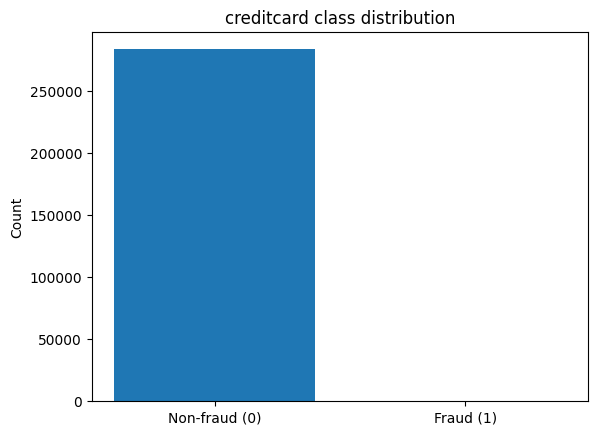

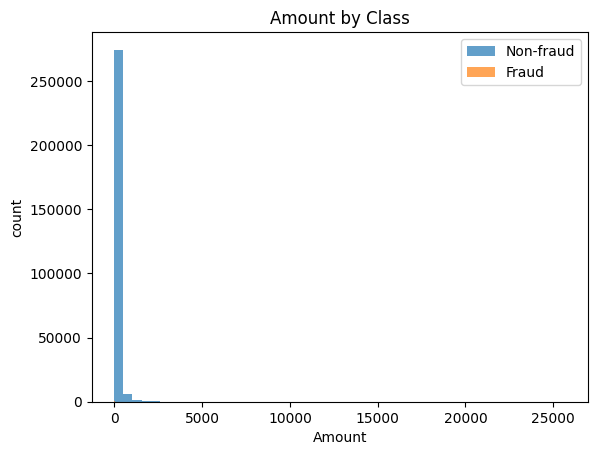

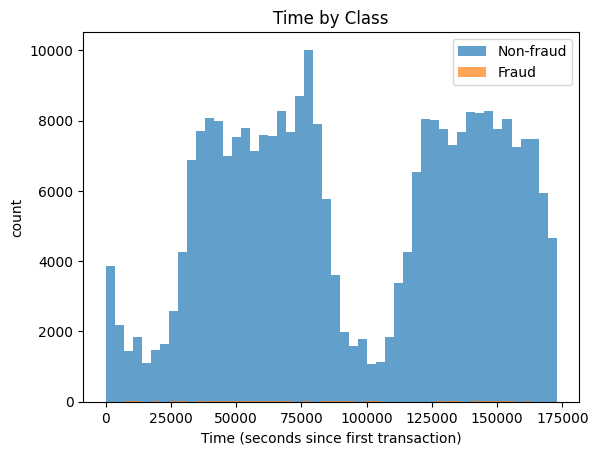

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

cc = pd.read_parquet("../data/processed/creditcard.parquet")
print(cc.shape)
display(cc.head())

print(cc["Class"].value_counts())
print("Fraud rate:", cc["Class"].mean())

counts = cc["Class"].value_counts().sort_index()
plt.figure()
plt.bar(["Non-fraud (0)", "Fraud (1)"], counts.values)
plt.title("creditcard class distribution")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(cc.loc[cc["Class"]==0, "Amount"], bins=50, alpha=0.7, label="Non-fraud")
plt.hist(cc.loc[cc["Class"]==1, "Amount"], bins=50, alpha=0.7, label="Fraud")
plt.title("Amount by Class")
plt.xlabel("Amount")
plt.ylabel("count")
plt.legend()
plt.show()

plt.figure()
plt.hist(cc.loc[cc["Class"]==0, "Time"], bins=50, alpha=0.7, label="Non-fraud")
plt.hist(cc.loc[cc["Class"]==1, "Time"], bins=50, alpha=0.7, label="Fraud")
plt.title("Time by Class")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("count")
plt.legend()
plt.show()

